# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
num_null = df.isnull().sum()
print(num_null)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [6]:
num_unknown_edu = (df['education'] == 'unknown').sum()
percent_unkown_edu = num_unknown_edu / len(df)
print(percent_unkown_edu)

0.042026803923472855


In [7]:
df.select_dtypes(include=['object', 'category']).nunique()

C:\Users\conno\AppData\Local\Temp\ipykernel_34504\179912453.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object', 'category']).nunique()


job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
y               2
dtype: int64

#### Data Shape Analysis
Upon taking a look at the shape of the data several key points become apparent.
- **No Null Values:**
  The data does not contain any explicit null values in any rows. Instead, some of the columns contain placeholders that represent null values, such as "unknown" in the `job`, `marital`, `education`, `default`, `housing` and `loan` columns and "999" as a sentinel value in the `pdays` column.
- **duration Column Note:**
  There is a note attached to the description of the `duration` column explaining that the duration value is not known before the output value is found. The duration of the call cannot be determined until after the call is complete and it is the conversation in the call that collects the information needed to determine whether the client has subscribed.
- **Cardinality:**
  The data contains a relatively high number of non-numerical columns. Most of these columns have a small number of unique values, between 3 and 5 possible values, but some of the columns have a high cardinality. The `job`, `education` and `month` columns have 12, 8 and 12 possible values, respectively. The `month` column is listed as having all 12 months as possible values, but the data itself only has 10 unique values for this column.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

#### Business Objective
Reducing the amount of money spent on failed conversions is paramount to reducing spending and maximizing profit. The goal of this project is to produce actionable information that can be used to help identify customers that are less likely to subscribe and avoid wasting resources on them.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [9]:
df_clean = df[df['education'] != 'unknown']

bank_info = df_clean[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']]
y = (df_clean['y'] == 'yes').astype(int)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

nominal_cols = ['job', 'marital', 'default', 'housing', 'loan']

education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school',
                    'professional.course', 'university.degree']

preprocessor = ColumnTransformer(transformers=[
    ('scale_age', StandardScaler(), ['age']),
    ('onehot_nominal', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    ('ordinal_education', OrdinalEncoder(categories=[education_order]), ['education']),
])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [11]:
from sklearn.model_selection import train_test_split

X = bank_info

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print(f'Train subscription rate: {y_train.mean():.4f}, Test subscription rate: {y_test.mean():.4f}')

Train shape: (31565, 7), Test shape: (7892, 7)
Train subscription rate: 0.1112, Test subscription rate: 0.1113


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [13]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)

baseline_train_acc = baseline_model.score(X_train, y_train)
baseline_test_acc = baseline_model.score(X_test, y_test)

In [14]:
print(f'Baseline (majority class) train accuracy: {baseline_train_acc:.4f}')
print(f'Baseline (majority class) test accuracy: {baseline_test_acc:.4f}')

Baseline (majority class) train accuracy: 0.8888
Baseline (majority class) test accuracy: 0.8887


#### Baseline Performance
Roughly 88.9% of clients did not subscribe to a term deposit, so a classifier that always predicts the majority class ('no') already achieves about 88.9% accuracy without learning anything. This is the baseline our models need to beat — accuracy below or near this level means the model adds no predictive value over simply guessing the majority class. Because the target is imbalanced (~11% positive), we should also look beyond accuracy at metrics like precision, recall, F1, or ROC-AUC when comparing models later on.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lgr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000)),
])

lgr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale_age', ...), ('onehot_nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

### Problem 9: Score the Model

What is the accuracy of your model?

In [17]:
LogReg_train_acc = lgr_pipeline.score(X_train, y_train)
LogReg_test_acc = lgr_pipeline.score(X_test, y_test)

print(f'Logistic Regression train accuracy: {LogReg_train_acc:.4f}')
print(f'Logistic Regression test accuracy: {LogReg_test_acc:.4f}')

Logistic Regression train accuracy: 0.8888
Logistic Regression test accuracy: 0.8887


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [18]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model),
    ])

    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    results.append({
        'Model': name,
        'Train Time': train_time,
        'Train Accuracy': pipe.score(X_train, y_train),
        'Test Accuracy': pipe.score(X_test, y_test),
    })

In [19]:
results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Time,Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.066004,0.888769,0.888748
KNN,0.029026,0.888642,0.876077
Decision Tree,0.455700,0.915318,0.866954
SVM,13.996837,0.888769,0.888748


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

#### Re-Engineering the dataset

##### 1. Re-Introducing dropped features
Adding some of the dropped features should help improve the model.
The only column that really needs to be excluded is `duration` due to the note attatched to that column.

In [40]:
full_df = df.drop(columns=['duration'])

##### 2. Handle sentinel values in pdays
The `pdays` column uses a sentinel value of 999 to indicate that the customer has never before been contacted. Instead, this sentinel value will be replaced with 0 and a new column called `was_previously_contacted` that holds a simple 0 or 1 to indicate if the customer has been contacted before.

In [41]:
# pdays uses 999 as a sentinel meaning "client was never previously contacted".
# Feeding 999 as a raw number distorts scaling and distance-based models (KNN/SVM),
# so we split the information into two clean features:
#   1. a binary flag capturing whether prior contact happened at all
#   2. the actual day count, with the sentinel collapsed to 0 (the flag preserves
#      the "never contacted" signal, so the magnitude is no longer misleading)
full_df = full_df.assign(
    was_previously_contacted=(full_df['pdays'] != 999).astype(int),
    pdays=full_df['pdays'].replace(999, 0),
)
full_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_previously_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


##### 3. Keep the 'unknown' education values
Keep the 'unknown' `education` values that were dropped earlier. By adding 'unknown' as the new lowest value on the scale for the `education` field, more rows and information is conserved.

In [42]:
# 'unknown' becomes the lowest code (0); real levels keep their relative order
education_order = ['unknown', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree']

# route every column type to a transformer so no feature is silently dropped
numeric_cols = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
                'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

nominal_cols = ['job', 'marital', 'default', 'housing', 'loan',
                'contact', 'month', 'day_of_week', 'poutcome']

preprocessor = ColumnTransformer(transformers=[
    ('scale_numeric', StandardScaler(), numeric_cols),
    ('onehot_nominal', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    ('ordinal_education', OrdinalEncoder(categories=[education_order]), ['education']),
    ('pass_flag', 'passthrough', ['was_previously_contacted']),
])

#### Re-create Train/Test Split

In [43]:
from sklearn.model_selection import train_test_split

X = full_df.drop(columns='y')
y = (full_df['y'] == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
print(f'Baseline (majority class) train accuracy: {baseline_train_acc:.4f}')
print(f'Baseline (majority class) test accuracy: {baseline_test_acc:.4f}')

Baseline (majority class) train accuracy: 0.8888
Baseline (majority class) test accuracy: 0.8887


#### Re-create Logistic Regression Model

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lgr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000)),
])

lgr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale_numeric', ...), ('onehot_nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [46]:
LogReg_train_acc = lgr_pipeline.score(X_train, y_train)
LogReg_test_acc = lgr_pipeline.score(X_test, y_test)

print(f'Logistic Regression train accuracy: {LogReg_train_acc:.4f}')
print(f'Logistic Regression test accuracy: {LogReg_test_acc:.4f}')

Logistic Regression train accuracy: 0.9003
Logistic Regression test accuracy: 0.9013


In [47]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model),
    ])

    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    results.append({
        'Model': name,
        'Train Time': train_time,
        'Train Accuracy': pipe.score(X_train, y_train),
        'Test Accuracy': pipe.score(X_test, y_test),
    })

In [48]:
results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Time,Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.190078,0.900303,0.901311
KNN,0.054017,0.911320,0.895606
Decision Tree,0.251601,0.995417,0.838674
SVM,28.959889,0.900212,0.900583


#### Hyperparameter Tuning with Grid Search
With the full feature set in place, we tune each model with `GridSearchCV`. Because the target is heavily imbalanced (~11% positive), we score on **F1 of the positive class** rather than accuracy, and let the models try `class_weight='balanced'` so the minority (subscribers) is not ignored.

In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score

search_spaces = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000),
        {'classifier__C': [0.01, 0.1, 1, 10],
         'classifier__class_weight': [None, 'balanced']},
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'classifier__n_neighbors': [11, 21, 31, 51],
         'classifier__weights': ['uniform', 'distance']},
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'classifier__max_depth': [3, 5, 10, 20],
         'classifier__min_samples_leaf': [1, 10, 50],
         'classifier__class_weight': [None, 'balanced']},
    ),
    'SVM': (
        SVC(random_state=42),
        {'classifier__C': [0.1, 1, 10],
         'classifier__class_weight': [None, 'balanced']},
    ),
}

grid_results = []
best_estimators = {}
for name, (model, param_grid) in search_spaces.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    grid = GridSearchCV(pipe, param_grid, scoring='f1', cv=5, n_jobs=-1)

    start = time.time()
    grid.fit(X_train, y_train)
    search_time = time.time() - start

    best_estimators[name] = grid.best_estimator_
    pred = grid.predict(X_test)
    grid_results.append({
        'Model': name,
        'Search Time': search_time,
        'Best CV F1': grid.best_score_,
        'Test F1': f1_score(y_test, pred),
        'Test Accuracy': accuracy_score(y_test, pred),
        'Best Params': grid.best_params_,
    })

In [50]:
grid_results_df = pd.DataFrame(grid_results).set_index('Model')
grid_results_df

,Search Time,Best CV F1,Test F1,Test Accuracy,Best Params
Model,,,,,
Logistic Regression,9.859272,0.450458,0.469348,0.835033,"{'classifier__C': 10, 'classifier__class_weigh..."
KNN,5.167039,0.359889,0.382688,0.901311,"{'classifier__n_neighbors': 11, 'classifier__w..."
Decision Tree,4.118145,0.457657,0.489967,0.851906,"{'classifier__class_weight': 'balanced', 'clas..."
SVM,397.983861,0.465813,0.492666,0.857247,"{'classifier__C': 10, 'classifier__class_weigh..."


#### Inspecting the Best Model: Classification Report & Confusion Matrix
Accuracy alone hides what the model actually does on the rare "yes" class. Below we take the model with the best test F1 and break down its precision/recall per class, then visualize the confusion matrix to see exactly how many subscribers we catch versus how many wasted contacts (false positives) that costs.

Best model by test F1: SVM

              precision    recall  f1-score   support

      no (0)       0.95      0.89      0.92      7310
     yes (1)       0.41      0.62      0.49       928

    accuracy                           0.86      8238
   macro avg       0.68      0.75      0.70      8238
weighted avg       0.89      0.86      0.87      8238



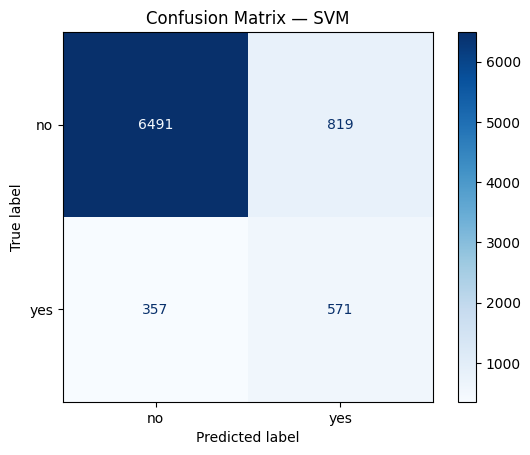

In [51]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# select the tuned model with the best test F1 from the grid search
best_name = max(grid_results, key=lambda r: r['Test F1'])['Model']
best_model = best_estimators[best_name]
y_pred = best_model.predict(X_test)

print(f'Best model by test F1: {best_name}\n')
print(classification_report(y_test, y_pred, target_names=['no (0)', 'yes (1)']))

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    display_labels=['no', 'yes'], cmap='Blues'
)
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

##### Questions